In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. Data Preparation**

- Load and merge pokemon.csv and combats.csv.

In [2]:
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')

df = pd.merge(pokemon, combats, left_on='#', right_on='First_pokemon')
df

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,First_pokemon,Second_pokemon,Winner
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,679,679
1,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,687,687
2,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,557,557
3,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,766,766
4,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,153,153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True,800,101,101
49996,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True,800,394,394
49997,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True,800,410,410
49998,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True,800,382,382


- Fix missing values:

In [3]:
df.isnull().sum()

,0
#,0
Name,56
Type 1,0
Type 2,24031
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


- - Fill the missing Name for Pokemon #63 (Primeape).

In [4]:
df['Name'][df['#'] == 63].isnull().sum()

56

In [5]:
df.loc[df['#'] == 63, 'Name'] = 'Primeape'

In [6]:
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,24031
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


- - Handle NaN values in Type 2 (mark as “None” if missing).


In [7]:
df['Type 2'] = df['Type 2'].fillna('None')

In [8]:
df.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0
Speed,0


- Calculate each Pokemon’s win percentage using the combat data.

In [9]:
# Since each Pokemon can appear in two different columns (First_pokemon and Second_pokemon),
# we need to count how many times each Pokémon participated in a battle.

# Count battles as First_pokemon
battles_as_first = combats['First_pokemon'].value_counts()

# Count battles as Second_pokemon
battles_as_second = combats['Second_pokemon'].value_counts()

# Sum both counts to get total battles
# Combines the number of battles for each Pokémon,
total_battles = battles_as_first.add(battles_as_second, fill_value=0)
print(total_battles)

# Count the number of times each Pokémon won
wins = combats['Winner'].value_counts()

# Calculate win percentage
win_percentage = (wins / total_battles) * 100

# Fill NaN (Pokémon that never won)
win_percentage = win_percentage.fillna(0)

# Convert Series (win_percentage) to DataFrame
win_percentage_df = win_percentage.reset_index()
win_percentage_df.columns = ['Pokemon ID', 'Win Percentage']

# Display top Pokemon by win percentage
win_percentage_df.sort_values(by='Win Percentage', ascending=False).head(20)

1      133
2      121
3      132
4      125
5      112
      ... 
796    105
797    131
798    119
799    144
800    121
Name: count, Length: 784, dtype: int64


,Pokemon ID,Win Percentage
147,155,98.449612
500,513,97.478992
688,704,96.800000
18,20,96.638655
146,154,96.453901
465,477,96.124031
711,727,96.062992
701,717,95.934959
157,165,95.200000
339,350,95.000000


In [10]:
# Merge with df dataset
df = pd.merge(df, win_percentage_df, left_on='#', right_on='Pokemon ID', how='left')

# Fill missing values (Pokemon that never fought)
df['Win Percentage'] = df['Win Percentage'].fillna(0)

# Drop redundant column
df = df.drop(columns=['Pokemon ID'])

# Check the dataset structure
df.head()


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,First_pokemon,Second_pokemon,Winner,Win Percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,679,679,27.819549
1,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,687,687,27.819549
2,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,557,557,27.819549
3,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,766,766,27.819549
4,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,1,153,153,27.819549


**2. Exploratory Analysis & Visualization**

- Create a correlation matrix to identify relationships between stats (HP, Attack, Speed) and win percentage.

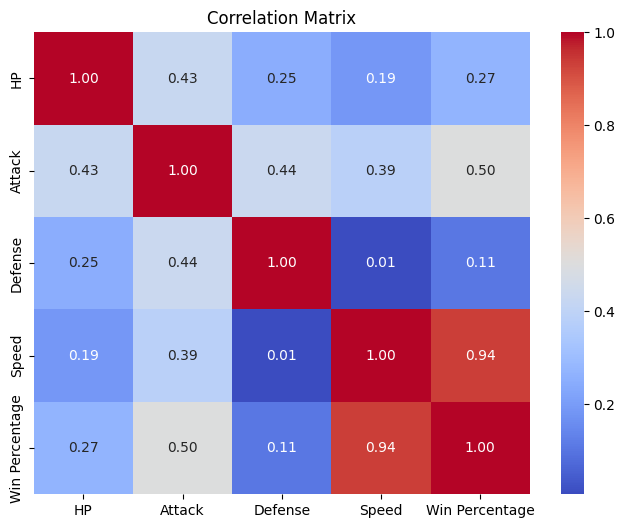

In [11]:
stats_columns = ['HP', 'Attack', 'Defense', 'Speed', 'Win Percentage']
correlation_matrix = df[stats_columns].corr()

# Display the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

*Speed* is the variable that influances the most win percentage of a pokemon.

- Plot a Seaborn pairplot or PairGrid for stats vs. win percentage.

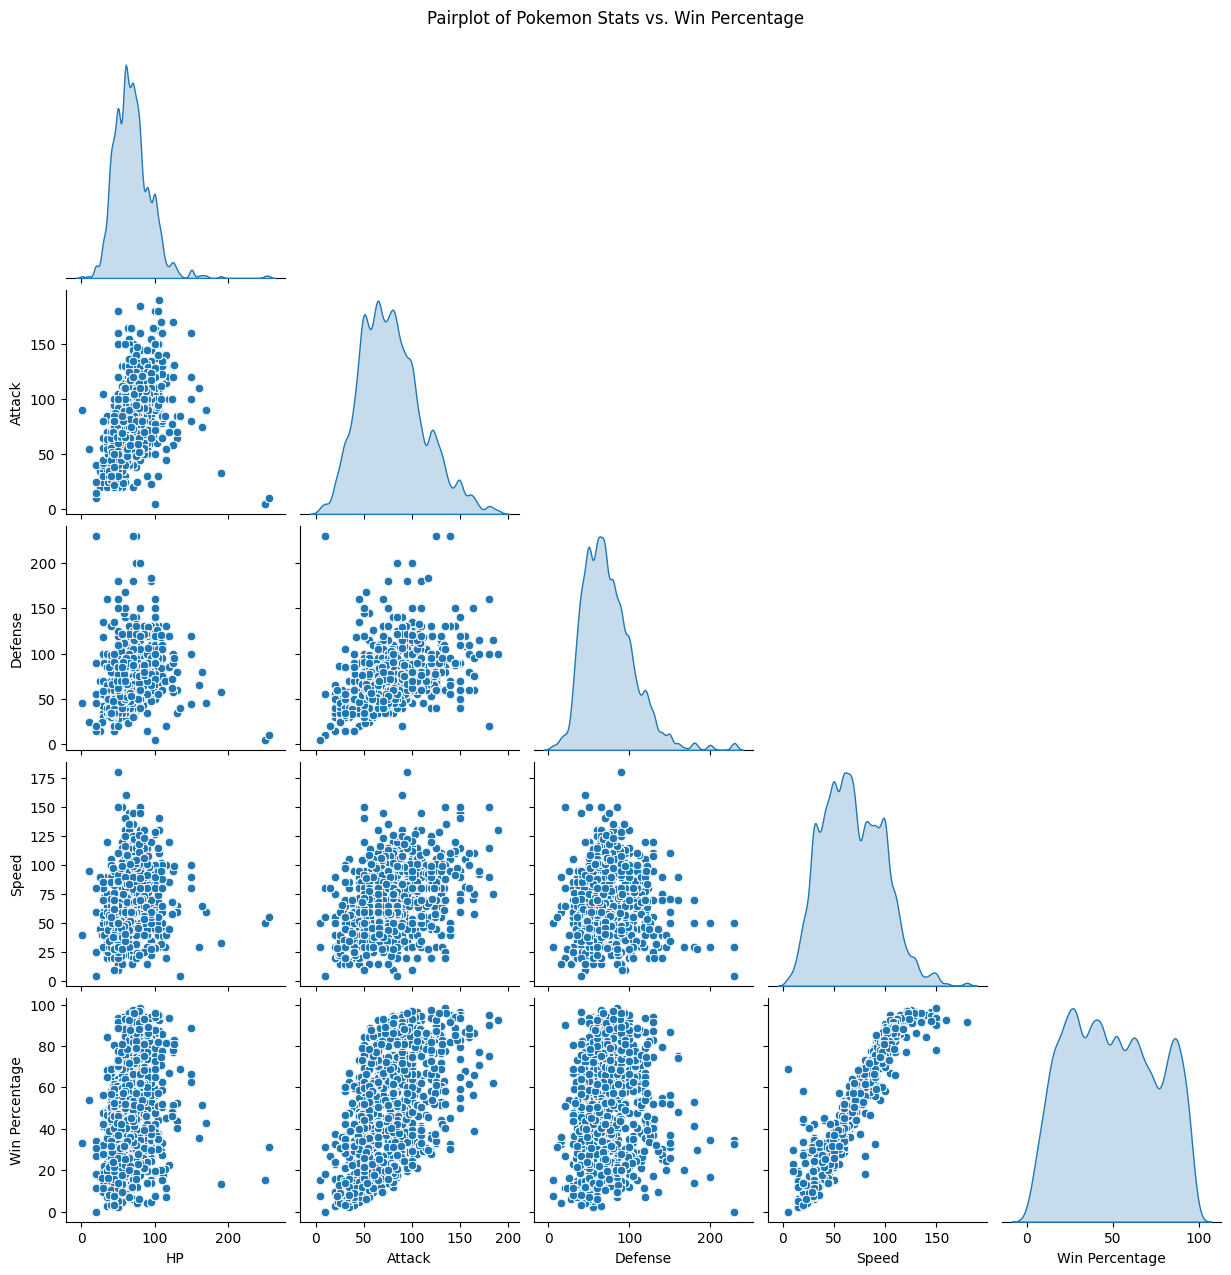

In [12]:
# Create a pairplot to visualize relationships
sns.pairplot(df[stats_columns], diag_kind='kde', corner=True)
plt.suptitle("Pairplot of Pokemon Stats vs. Win Percentage", y=1.02)
plt.show()

We can see the almost linear correlation between *Speed* and *Win Percentage* that confirms what the correlation matrix shows.
The more *Speed* increases, the more *Win Percentage* also increases.

- Analyze the top 10 Pokemon by win percentage and their stats.

In [13]:
# first() : These stats don’t change between the rows of the same pokemon, so we just keep the first value.
top_10_pokemon = df.groupby('#')\
                      .first()\
                      .sort_values(by='Win Percentage', ascending=False)\
                      .head(10)[['Name'] + stats_columns]
top_10_pokemon

,Name,HP,Attack,Defense,Speed,Win Percentage
#,,,,,,
155,Mega Aerodactyl,80,135,85,150,98.449612
513,Weavile,70,120,65,125,97.478992
704,Tornadus Therian Forme,79,100,80,121,96.800000
20,Mega Beedrill,65,150,40,145,96.638655
154,Aerodactyl,80,105,65,130,96.453901
477,Mega Lopunny,65,136,94,135,96.124031
727,Greninja,72,95,67,122,96.062992
717,Meloetta Pirouette Forme,100,128,90,128,95.934959
165,Mega Mewtwo Y,106,150,70,140,95.200000


**3. Machine Learning**

- Split data into training/testing sets (80/20 split).

In [14]:
from sklearn.model_selection import train_test_split

# Drop 'Win Percentage' and 'Name' from X, keep all other features
X = df.drop(columns=['Win Percentage', 'Name'])

# Convert categorical features ('Type 1', 'Type 2') into numeric values using one-hot encoding
X = pd.get_dummies(X, columns=['Type 1', 'Type 2'])

# Define target variable
y = df['Win Percentage'] # target

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

- *Linear Regression:*

In [15]:
from sklearn.linear_model import LinearRegression

# Initialize model
linear_model = LinearRegression()

#Train model
linear_model.fit(X_train, y_train)

# Make prediction
y_pred_linear = linear_model.predict(X_test)

# Print model score
print(f"Linear Model Score : {linear_model.score(X_train, y_train)}")


Linear Model Score : 0.9221712590393716


- *Random Forest:*

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Make prediction
y_pred_rf = rf_model.predict(X_test)

# Print model score
print(f"Random Forest Regressor Score : {rf_model.score(X_train, y_train)}")

Random Forest Regressor Score : 0.9999999904394525


**Reducing overfitting**

In [17]:
# Initialize the model
rf_model2 = RandomForestRegressor(
    n_estimators=50,       # Reduce the number of trees (default is 100)
    max_depth=5,           # Limit tree depth to prevent deep memorization
    min_samples_split=10,  # Require at least 10 samples to split a node
    min_samples_leaf=5,    # Require at least 5 samples in a leaf node
    random_state=42
)
# Train model
rf_model2.fit(X_train, y_train)

# Make prediction
y_pred_rf2 = rf_model2.predict(X_test)

# Print model score
print(f"Random Forest Regressor Score : {rf_model2.score(X_train, y_train)}")

Random Forest Regressor Score : 0.9674137753906262


- *XGboost:*

In [18]:
from xgboost import XGBRegressor

# Initialize the model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)

# Train model
xgb_model.fit(X_train, y_train)

# Make prediction
y_pred_xgb = xgb_model.predict(X_test)

# Print model score
print(f"XGB Regressor Score : {xgb_model.score(X_train, y_train)}")


XGB Regressor Score : 0.9998957816966815


**Reducing overfitting**

In [19]:
# Initialize the model
xgb_model2 = XGBRegressor(
    n_estimators=50,        # Reduce the number of boosting rounds
    max_depth=4,            # Limit tree depth (prevents overfitting)
    learning_rate=0.1,      # Reduce how much each tree impacts predictions
    subsample=0.8,          # Use only 80% of data per tree (reduces dependency)
    colsample_bytree=0.8,   # Use 80% of features per tree (improves generalization)
    reg_lambda=1,           # L2 regularization (prevents overfitting)
    random_state=42
)

# Train model
xgb_model2.fit(X_train, y_train)

# Make prediction
y_pred_xgb2 = xgb_model2.predict(X_test)

# Print model score
print(f"XGB Regressor Score : {xgb_model2.score(X_train, y_train)}")

XGB Regressor Score : 0.983533077766369


- Compare model performance using Mean Absolute Error (MAE).

In [20]:
from sklearn.metrics import mean_absolute_error

print(f"Mean linear model : {mean_absolute_error(y_test, y_pred_linear)}")
print(f"Mean rf model : {mean_absolute_error(y_test, y_pred_rf)}")
print(f"Mean XGB model : {mean_absolute_error(y_test, y_pred_xgb)}")

Mean linear model : 5.292749080848264
Mean rf model : 0.00012484975789260546
Mean XGB model : 0.1622453344781327


In [21]:
# After applying regularization techniques
print(f"Mean rf model : {mean_absolute_error(y_test, y_pred_rf2)}")
print(f"Mean XGB model : {mean_absolute_error(y_test, y_pred_xgb2)}")

Mean rf model : 3.6454506344897157
Mean XGB model : 2.686637887524003


**Conclusion and Insights :**

1. **R^2** (coefficient of determination) tells us how well the model explains the variance in the data.
 - 1.0 → Perfect fit (model explains 100% of variance)
 - 0.0 → Model explains nothing
 - Negative → Worse than a random guess

**Linear Regression : 92%**
 - The model captures 92% of the variance in Pokemon win percentage. It performs well, but not perfectly, meaning some variation in win percentage is not fully explained.

**Random Forest : ≈100%**
 - The model is almost perfect predicting the win percentage. But this could be overfitting, it may memorizing the data instead of generalizing.

**XGBoost : 0.9999%**
 - It is almost as good as Random Forest. It performs exceptionally well but may also be too perfect, indicating overfitting risk.
------------------------------------------------
2. **Mean Squared Error** mesures how far predictions are from acual values. Lower MSE means better predictions.

**Linear Regression : 5.29%**
 - Predictions are fairly close to actual win percentages. There is some error, but it's not terrible.

**Random Forest : 0.00012%**
- Extremly low error, indicating almost perfect predictions. This suggests overfitting, the model might not generalize well the new data.

**XGBoost : 0.16%**
- Also very low error, but slightly higher than Random performance. It shows excellent performance.

Since **Random Forest** and **XGBoost** might be overfitting because their scores are too perfect, we could improve them by adjusting the hyperparameters (reduce n_estimator, modify depth restriction) to make it generalize better.

------------------------------------------------

After applying regularization techniques to reduce overfitting, the **model score** and the **average error** have changed :
- **Random Forest : 96.7% accuracy with an average error of only 3.65%**
- **XGBoost : 98.35% accuracy with an average error of only 2.69%**
--> The regularization improves generalization, ensuring the models perform well on new data.

**XGBoost (98.35%) outperforms Random Forest (96.74%)**, making it the **best choice** for predicting Pokemon win percentage.

